<div class="alert alert-block alert-info">
<b>Welcome to SynEdu!</b> This talktorial is part of <b>SynEdu</b>, a lightweight teaching series built around the <b>Syn</b> ecosystem and <b>RDKit</b> for practical, reproducible cheminformatics.
</div>

<div class="alert alert-block alert-success">
<b>By the end of this notebook</b>, you will be able to take a SMILES string and produce a clean, inspectable <b>typed molecular graph</b> (NetworkX) that is ready for later steps like <i>reaction center detection</i> and <i>DPO rule extraction</i>.
</div>

<div class="alert alert-block alert-warning">
<b>Reproducibility first</b>: Keep runtime short, prefer small datasets, and pin dependencies (e.g., via <code>environment.yml</code>). Save version info alongside exported figures.
</div>

# S000 · Molecules → Typed Graphs (RDKit → NetworkX)

### Why this talktorial exists

Reaction modeling by **graph transformation** starts with a reliable bridge:

> **SMILES → RDKit Mol → NetworkX Graph (typed attributes)**

RDKit remains the source of chemical truth (sanitization, aromaticity perception, valence),
while NetworkX provides a flexible representation for graph algorithms and prototyping.

---

## Learning outcomes

After finishing this notebook, you can:

- Convert SMILES into a typed graph (**atoms → nodes**, **bonds → edges**)
- Preserve essential attributes:
  - Node: **element**, **atomic number**, **aromaticity**, **formal charge**, **H-count**, **ring membership**
  - Edge: **bond order**, **aromatic flag**, **conjugation**, **ring membership**
- Export graphs for inspection and downstream use (**DOT**, **GraphML**, **node-link JSON**)

**Data:** `data/molecules.csv`

<div class="alert alert-block alert-info">
<b>Estimated time</b>: ~10–15 minutes (plus optional exercises).
</div>


## Authors and contributions

- Tieu-Long Phan, Peter Stadler group, Professur für Bioinformatik, Institut für Informatik, Universität Leipzig
- (Add contributors here)

<div class="alert alert-block alert-info">
<b>Cross-referencing</b>: When referring to another SynEdu notebook, use <b>Talktorial SXX</b> (e.g., <b>Talktorial S03</b>).
</div>


## Roadmap

### Concepts (short)
1. Molecules as labeled graphs (what is a node/edge attribute?)
2. What to keep in NetworkX vs what must remain in RDKit
3. A minimal attribute schema that stays stable across SynEdu notebooks

### Practical steps
1. Load SMILES from `data/molecules.csv`
2. Convert RDKit Mol → NetworkX graph
3. Inspect node/edge tables (sanity checks)
4. Export DOT/GraphML/JSON for reuse


# Theory

## Molecules as labeled graphs

A molecular graph is typically represented as:
- **Nodes** = atoms (with attributes like element, charge, aromaticity)
- **Edges** = bonds (with attributes like bond order, aromatic flag)

## RDKit vs NetworkX (division of labor)

- Use **RDKit** for: sanitization, aromaticity perception, valence rules, canonical SMILES, depiction.
- Use **NetworkX** for: subgraph extraction, neighborhood queries, matching prototypes, graph rewriting prototypes.

<div class="alert alert-block alert-info">
<b>Key takeaway</b>: graphs in SynEdu are <i>derived</i> objects. If something looks wrong, verify it in RDKit first.
</div>


# Practical

In this section we implement a small, reusable conversion:
- `mol_to_nx(mol)` converts an RDKit Mol into a NetworkX graph.
- We then validate counts and export the graph in a few formats.


In [ ]:
from __future__ import annotations

from pathlib import Path
import pandas as pd
import networkx as nx

from rdkit import Chem
from rdkit.Chem import Draw


try:
    import synkit  # type: ignore
    HAS_SYNKit = True
except Exception:
    HAS_SYNKit = False

# Output directory
OUT = Path("talktorials/out")
OUT.mkdir(parents=True, exist_ok=True)

# Record versions for reproducibility
import rdkit
import networkx as nx
print("RDKit:", rdkit.__version__)
print("NetworkX:", nx.__version__)
print("SynKit available:", HAS_SYNKit)


RDKit: 2025.09.3
NetworkX: 3.6.1
SynKit available: True


In [5]:
# Load molecules
df = pd.read_csv("data/molecules.csv")
df.head()


,smiles,name
0,CCO,ethanol
1,CCCl,chloroethane
2,CCOCC,diethyl ether
3,O,water
4,C(C(=O)O)N,glycine


In [6]:
def mol_to_nx(mol: Chem.Mol) -> nx.Graph:
    """Convert an RDKit molecule to a typed NetworkX graph.

    Node attributes (atoms):
      - symbol, atomic_num, aromatic, charge
      - total_h, degree, in_ring
      - hybridization (string), chiral_tag (string)

    Edge attributes (bonds):
      - order (int), aromatic (bool), conjugated (bool), in_ring (bool)

    Notes
    -----
    - This is a *minimal, stable* schema intended for SynEdu talktorials.
    - RDKit remains the chemical ground truth (sanitization/valence/etc.).
    """
    G = nx.Graph()

    for a in mol.GetAtoms():
        G.add_node(
            a.GetIdx(),
            symbol=a.GetSymbol(),
            atomic_num=int(a.GetAtomicNum()),
            aromatic=bool(a.GetIsAromatic()),
            charge=int(a.GetFormalCharge()),
            total_h=int(a.GetTotalNumHs()),
            degree=int(a.GetDegree()),
            in_ring=bool(a.IsInRing()),
            hybridization=str(a.GetHybridization()),
            chiral_tag=str(a.GetChiralTag()),
        )

    for b in mol.GetBonds():
        G.add_edge(
            b.GetBeginAtomIdx(),
            b.GetEndAtomIdx(),
            order=int(b.GetBondTypeAsDouble()),
            aromatic=bool(b.GetIsAromatic()),
            conjugated=bool(b.GetIsConjugated()),
            in_ring=bool(b.IsInRing()),
        )
    return G


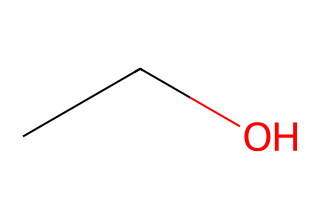

name=ethanol  smiles=CCO
N atoms (RDKit): 3  | N nodes (NX): 3
N bonds (RDKit): 2  | N edges (NX): 2


In [7]:
# Pick an example molecule and convert
example = df.iloc[0]
smiles = example["smiles"]
name = example.get("name", "example")

mol = Chem.MolFromSmiles(smiles)
assert mol is not None, f"RDKit failed to parse SMILES: {smiles}"

display(Draw.MolToImage(mol, size=(320, 220)))

G = mol_to_nx(mol)
print(f"name={name}  smiles={smiles}")
print("N atoms (RDKit):", mol.GetNumAtoms(), " | N nodes (NX):", G.number_of_nodes())
print("N bonds (RDKit):", mol.GetNumBonds(), " | N edges (NX):", G.number_of_edges())


In [8]:
# Inspect nodes/edges as tables (great for debugging)
nodes_df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient="index")
edges_df = pd.DataFrame(
    [(u, v, *d.values()) for u, v, d in G.edges(data=True)],
    columns=["u", "v"] + list(next(iter(G.edges(data=True)))[2].keys()) if G.number_of_edges() else ["u", "v"]
)

display(nodes_df)
display(edges_df)


,symbol,atomic_num,aromatic,charge,total_h,degree,in_ring,hybridization,chiral_tag
0,C,6,False,0,3,1,False,SP3,CHI_UNSPECIFIED
1,C,6,False,0,2,2,False,SP3,CHI_UNSPECIFIED
2,O,8,False,0,1,1,False,SP3,CHI_UNSPECIFIED


,u,v,order,aromatic,conjugated,in_ring
0,0,1,1,False,False,False
1,1,2,1,False,False,False


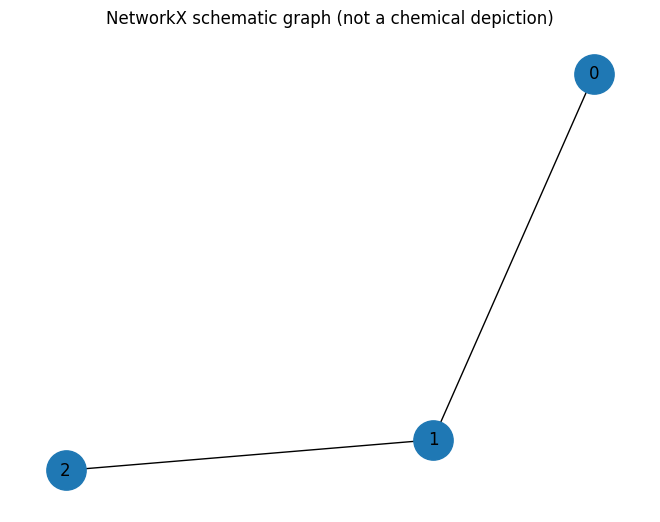

In [9]:
# Optional: quick NetworkX drawing (schematic, not chemical)
try:
    import matplotlib.pyplot as plt
    pos = nx.spring_layout(G, seed=0)
    nx.draw(G, pos, with_labels=True, node_size=800)
    plt.title("NetworkX schematic graph (not a chemical depiction)")
    plt.show()
except Exception as e:
    print("Skipping matplotlib drawing:", e)


DOT export skipped (install pydot + graphviz): No module named 'pydot'
Wrote talktorials/out/S00_example.graphml
Wrote talktorials/out/S00_example.node_link.json


In [11]:
# Optional: read-back test (sanity)
from networkx.readwrite import json_graph
import json
nl2 = json.loads((OUT / "S00_example.node_link.json").read_text(encoding="utf-8"))
G2 = json_graph.node_link_graph(nl2)
print("Round-trip nodes:", G2.number_of_nodes(), "edges:", G2.number_of_edges())


Round-trip nodes: 3 edges: 2


## Exercises (optional)

1. Add `atom_map_num` to nodes (useful later for mapped reactions).
2. Add `bond_type` as a string to edges (e.g., SINGLE/DOUBLE/AROMATIC).
3. Write a function `batch_convert(csv_path) -> list[Graph]` that exports one GraphML per molecule.


# Discussion

## What did we gain?

- An explicit, inspectable graph representation for molecules
- A stable attribute schema that can be reused across later notebooks

## What did we *not* solve yet?

- **Chemical validity after edits**: once you start rewriting graphs, you must re-check valence/charges.
- **Stereochemistry**: this notebook stores only minimal chirality information (optional).
- **Disconnected graphs**: SMILES can describe mixtures; decide whether to model as one graph or separate components.

## Practical advice for the next notebooks (reaction modeling)

- Keep RDKit objects around as the *ground truth*.
- Use NetworkX graphs for algorithms and bookkeeping (matches, neighborhoods, rule contexts).
- When you export, always export:
  - the graph **and**
  - enough metadata to reconstruct the RDKit molecule (e.g., original SMILES, RDKit canonical SMILES, RDKit version).


# Quiz

Answer briefly (or implement the small coding tasks).

1. **Node attributes**: Which *three* atom attributes are most important for later reaction modeling, and why?
2. **Edge attributes**: How would you represent a bond order change (single→double) in an edge attribute?
3. **Ring membership**: Why might ring membership matter for rule extraction?
4. **Coding**: Extend `mol_to_nx` to store `chiral_tag` and `hybridization`.
5. **Export**: Which export format would you pick for (a) human inspection, (b) programmatic round-trip? Explain.

<div class="alert alert-block alert-info">
<b>Optional challenge</b>: Implement `nx_to_smiles` (hard!) or explain why it is difficult without a chemistry toolkit.
</div>


# References and further reading

*Suggested citation style:*  
* Keyword: <i>Source</i> (year) (link)

- RDKit documentation: <i>RDKit</i> (ongoing) — https://www.rdkit.org/docs/
- RDKit Book: <i>The RDKit Book</i> (ongoing) — https://www.rdkit.org/docs/Book.html
- NetworkX documentation: <i>NetworkX</i> (ongoing) — https://networkx.org/documentation/stable/
- NetworkX JSON node-link format: <i>NetworkX</i> (ongoing) — https://networkx.org/documentation/stable/reference/readwrite/json_graph.html
- Graphviz DOT language: <i>Graphviz</i> (ongoing) — https://graphviz.org/documentation/
